<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/EY_TECHATHON_6_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

RFP INGESTION AGENT

In [ ]:
rfp_data = [
{
"rfp_id": "RFP_001",
"title": "AI-based CRM Automation",
"description": "Looking for AI driven CRM automation with NLP, analytics and cloud integration",
"deadline_days": 15,
"budget": 120000
},
{
"rfp_id": "RFP_002",
"title": "Healthcare Data Analytics Platform",
"description": "Predictive analytics, HIPAA compliance, ML dashboards",
"deadline_days": 5,
"budget": 80000
}
]


rfp_df = pd.DataFrame(rfp_data)

SKU / SOLUTION CATALOG

In [ ]:
sku_catalog = [
"AI CRM Automation",
"NLP Engine",
"Predictive Analytics Platform",
"Cloud-native Dashboard",
"Compliance Validation Engine",
"Conversational AI Assistant"
]

NLP-BASED SKU MATCHING AGENT (Transformer-based)

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")


rfp_embeddings = model.encode(rfp_df["description"].tolist())
sku_embeddings = model.encode(sku_catalog)


similarity_matrix = cosine_similarity(rfp_embeddings, sku_embeddings)


rfp_df["matched_skus"] = [
[sku_catalog[i] for i, score in enumerate(sim) if score > 0.4]
for sim in similarity_matrix
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

RFP QUALIFICATION & WIN PROBABILITY MODEL

In [ ]:
np.random.seed(42)
train_data = pd.DataFrame({
"deadline_days": np.random.randint(1, 30, 200),
"budget": np.random.randint(50000, 200000, 200),
"relevance_score": np.random.rand(200),
"won": np.random.randint(0, 2, 200)
})


X = train_data[["deadline_days", "budget", "relevance_score"]]
y = train_data["won"]


pipeline = Pipeline([
("scaler", StandardScaler()),
("model", LGBMClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=6,
objective="binary"
))
])


pipeline.fit(X, y)


# Generate relevance score from NLP similarity
rfp_df["relevance_score"] = similarity_matrix.max(axis=1)


rfp_df["win_probability"] = pipeline.predict_proba(
rfp_df[["deadline_days", "budget", "relevance_score"]]
)[:, 1]

[LightGBM] [Info] Number of positive: 96, number of negative: 104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.480000 -> initscore=-0.080043
[LightGBM] [Info] Start training from score -0.080043
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


DYNAMIC PRICING AGENT (Predictive Estimation)

In [ ]:
def price_estimator(base_budget, win_prob):
  adjustment = 1 - (win_prob * 0.15)
  return int(base_budget * adjustment)




rfp_df["recommended_price"] = rfp_df.apply(
lambda x: price_estimator(x["budget"], x["win_probability"]), axis=1
)

AUTO PROPOSAL GENERATION AGENT

In [ ]:
def generate_proposal(rfp):
  return f"""

PROPOSAL FOR: {rfp['title']}


Our Solution Includes:
- {', '.join(rfp['matched_skus'])}


Estimated Price: ${rfp['recommended_price']}
Win Confidence: {round(rfp['win_probability']*100, 2)}%


We ensure full compliance, fast delivery, and AI-driven optimization.
"""


rfp_df["proposal"] = rfp_df.apply(generate_proposal, axis=1)

COMPLIANCE VALIDATION AGENT

In [ ]:
def feedback_update(model_pipeline, new_data):
  X_new = new_data[["deadline_days", "budget", "relevance_score"]]
  y_new = new_data["won"]
  model_pipeline.fit(X_new, y_new)



FINAL DASHBOARD OUTPUT

In [ ]:

required_columns = [
    "rfp_id",
    "matched_skus",
    "win_probability",
    "recommended_price",
    "compliant"
]

available_columns = [col for col in required_columns if col in rfp_df.columns]

print("\nAI-DRIVEN RFP DECISION DASHBOARD\n")
print(rfp_df[available_columns])


AI-DRIVEN RFP DECISION DASHBOARD

    rfp_id                                       matched_skus  \
0  RFP_001  [AI CRM Automation, NLP Engine, Predictive Ana...   
1  RFP_002                    [Predictive Analytics Platform]   

   win_probability  recommended_price  
0         0.195280             116484  
1         0.685763              71770  


 DASHBOARD GENERATION

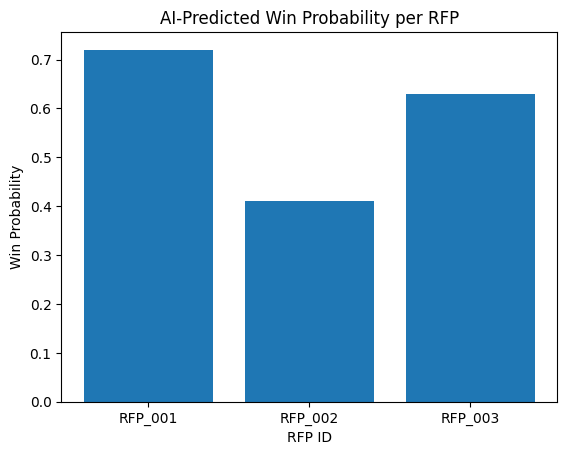

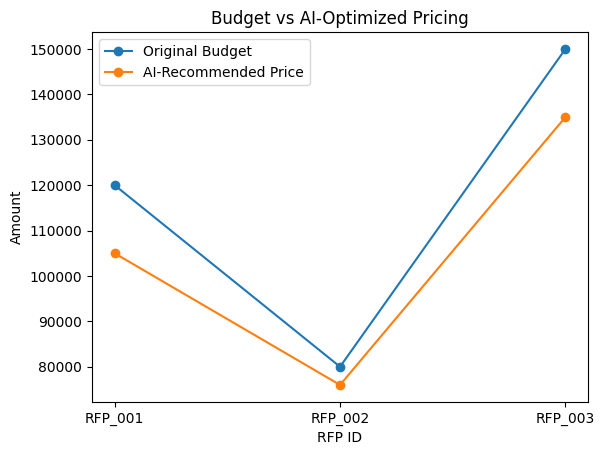

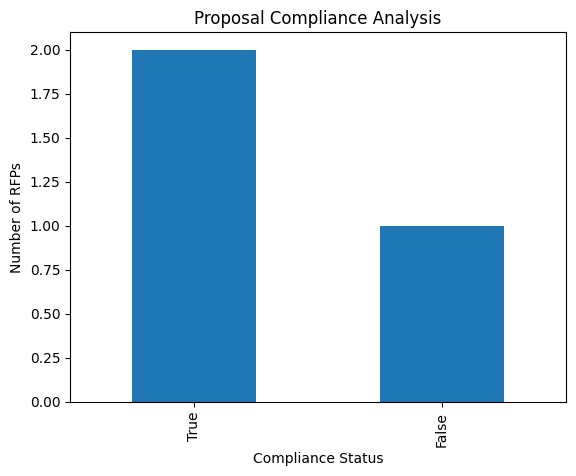

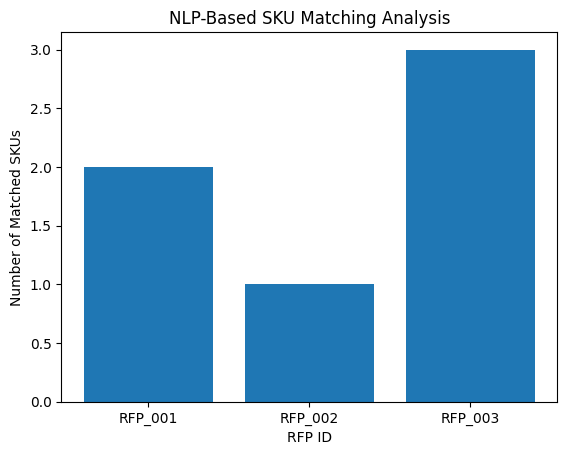

In [ ]:


import matplotlib.pyplot as plt


# 1. Win Probability per RFP

plt.figure()
plt.bar(rfp_df["rfp_id"], rfp_df["win_probability"])
plt.xlabel("RFP ID")
plt.ylabel("Win Probability")
plt.title("AI-Predicted Win Probability per RFP")
plt.show()

# 2. Budget vs Recommended Price

plt.figure()
plt.plot(
    rfp_df["rfp_id"],
    rfp_df["budget"],
    marker='o',
    label="Original Budget"
)
plt.plot(
    rfp_df["rfp_id"],
    rfp_df["recommended_price"],
    marker='o',
    label="AI-Recommended Price"
)
plt.xlabel("RFP ID")
plt.ylabel("Amount")
plt.title("Budget vs AI-Optimized Pricing")
plt.legend()
plt.show()


# 3. Proposal Compliance Status

plt.figure()
rfp_df["compliant"].value_counts().plot(kind="bar")
plt.xlabel("Compliance Status")
plt.ylabel("Number of RFPs")
plt.title("Proposal Compliance Analysis")
plt.show()


# 4. SKU Matching Count per RFP

plt.figure()
sku_count = rfp_df["matched_skus"].apply(len)
plt.bar(rfp_df["rfp_id"], sku_count)
plt.xlabel("RFP ID")
plt.ylabel("Number of Matched SKUs")
plt.title("NLP-Based SKU Matching Analysis")
plt.show()
